In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Implementación de Regresión Logística con aprobados / suspensos

Creo el dataset de horas estudiadas y aprobado / suspenso. Para esto uso una función que para las horas estudiadas nos da un número. Este número no tiene interpretación. 

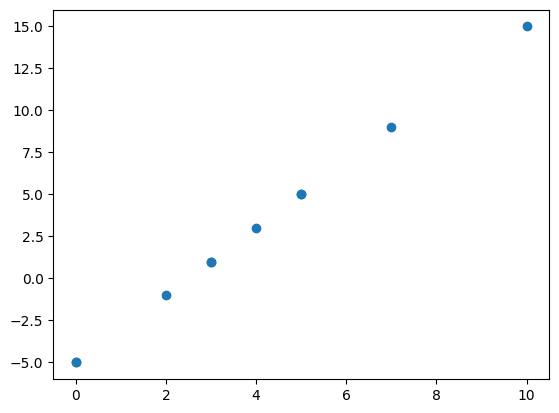

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import matplotlib.pyplot as plt
from regresion_logistica import sigmoide 

x = np.array([0,0,3,4,5,10,7,5,3,2])

a_real = 2
b_real = -5

z = a_real*x + b_real

plt.scatter(x,z)



Ahora tenemos relacionadas las horas de estudio con un "número". Vamos a aplastar ese número usando la sigmoide para obtener una probablilidad para cada uno de 1 a 0. (esta es la probabilidad de aprobar)

In [3]:

p = sigmoide(z)
print(z)
print(p)

[-5 -5  1  3  5 15  9  5  1 -1]
[0.00669285 0.00669285 0.73105858 0.95257413 0.99330715 0.99999969
 0.99987661 0.99330715 0.73105858 0.26894142]


Vamos a traducir las probabilidades de aprobar a eventos que han ocurrido. Para esto tiraremos una moneda cargada para cada alumno con el número, a ver si tiene suerte o no. 

Así obtenemos el array de aprobados / suspensos. 

In [4]:
y = np.random.binomial(1,p)
print(y)

[0 0 0 1 1 1 1 1 1 0]


Representación: 

Eje x = horas estudiadas
Eje y (línea roja) = sigmoide que determina la probabilidad de aprobar según las horas estudiadas
Eje y (puntos) = eventos reales en los que los alumnos han aprobado o suspendido según sus horas de estudio. 

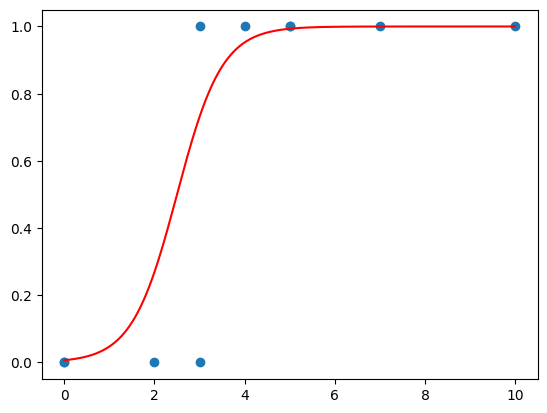

In [5]:
x_continuo = np.linspace(0,10,1000)
plt.scatter(x,y)
plt.plot(x_continuo, sigmoide(a_real*x_continuo + b_real ), color = "red")

## Defino la función de coste:

Se usa la función binary cross-entropy. (definida en otro archivo de python)

Se ve que con los parámetros reales que debemos buscar efectivamente la función de coste es menor que con parámetros como a=0 b=0. 

In [16]:
x = np.array([0,0,3,4,5,10,7,5,3,2])
y = np.array([0,0,1,1,1,1,1,1,1,1])
p = np.array([0.00669285, 0.00669285, 0.73105858, 0.95257413, 0.99330715, 0.99999969,
 0.99987661, 0.99330715, 0.73105858, 0.26894142])

from regresion_logistica import coste

print(coste(x,y,0,0))
print(coste(x, y, 2, -5))


0.6931471805599453
0.20153575161768797


## Derivar la función de coste para obtener el gradiente (pasado de mis apuntes en el iPad)

$$p = \text{sigmoide}(z) = \frac{1}{1+e^{-z}}$$
$$z = ax_i+b$$

**Función de coste**

$$\text{coste} = -y_i \ln(p_i) - (1-y_i) \ln(1-p_i)$$
$$\text{coste} = -y_i \ln(\text{sigmoide}(ax_i+b)) - (1-y_i) \ln(1-\text{sigmoide}(ax_i+b))$$

**Derivada de la función sigmoide:**

$$
\begin{aligned}
\frac{\partial}{\partial z} \left( \frac{1}{1+e^{-z}} \right) &= \frac{0 \cdot (1+e^{-z}) - 1(e^{-z}(-1))}{(1+e^{-z})^2} = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{(1+e^{-z})} \cdot \frac{1}{(1+e^{-z})} \cdot e^{-z} \\
&= \text{sigmoide}(z) \cdot \frac{1}{(1+e^{-z})} \cdot e^{-z} = \text{sigmoide}(z) \cdot \frac{e^{-z}}{(1+e^{-z})} \\
&= \text{sigmoide}(z) \frac{1 + e^{-z} - 1}{(1+e^{-z})} = \text{sigmoide}(z) \left( \frac{(1+e^{-z})}{(1+e^{-z})} - \frac{1}{(1+e^{-z})} \right) \\
&= \text{sigmoide}(z) (1 - \text{sigmoide}(z))
\end{aligned}
$$

**Derivada del coste respecto a $a$:**

$$
\begin{aligned}
\frac{\partial \text{coste}}{\partial a} &= -y_i \frac{1 \cdot \cancel{\text{sigmoide}(ax_i+b)}(1-\text{sigmoide}(ax_i+b)) \cdot x_i}{\cancel{\text{sigmoide}(ax_i+b)}} + (1-y_i) \frac{\text{sigmoide}(ax_i+b)\cancel{(1-\text{sigmoide}(ax_i+b))}}{\cancel{1-\text{sigmoide}(ax_i+b)}} \cdot x_i \\
&= -y_i x_i (1-\text{sigmoide}(ax_i+b)) + (1-y_i) x_i \text{sigmoide}(ax_i+b) \\
&= -x_i \Big( y_i (1-\text{sigmoide}(ax_i+b)) - (1-y_i) \text{sigmoide}(ax_i+b) \Big) \\
&= -x_i ( y_i - y_i \cancel{\text{sigmoide}(ax_i+b)} - \text{sigmoide}(ax_i+b) + y_i \cancel{\text{sigmoide}(ax_i+b)} ) \\
&= -x_i (y_i - \text{sigmoide}(ax_i+b))
\end{aligned}
$$

**Derivada del coste respecto a $b$:**

$$
\begin{aligned}
\frac{\partial \text{coste}}{\partial b} &= -y_i \frac{1 \cdot \cancel{\text{sigmoide}(ax_i+b)}(1-\text{sigmoide}(ax_i+b))}{\cancel{\text{sigmoide}(ax_i+b)}} + (1-y_i) \frac{\text{sigmoide}(ax_i+b)\cancel{(1-\text{sigmoide}(ax_i+b))}}{\cancel{1-\text{sigmoide}(ax_i+b)}} \\
&= -y_i (1-\text{sigmoide}(ax_i+b)) + (1-y_i) \text{sigmoide}(ax_i+b) \\
&= -y_i + y_i \cancel{\text{sigmoide}(ax_i+b)} + \text{sigmoide}(ax_i+b) - y_i \cancel{\text{sigmoide}(ax_i+b)} \\
&= -y_i + \text{sigmoide}(ax_i+b)
\end{aligned}
$$

**Gradiente final:**
$$\nabla \text{coste} (a,b) = \Big( -x_i (y_i - \text{sigmoide}(ax_i+b)), -y_i + \text{sigmoide}(ax_i+b) \Big)$$

Ese es el coste individual para unos parámetros a b, pero quiero que el coste se minimice para todos los puntos del dataset, entonces se hace la media.

$$ \frac{\partial  C}{\partial a} = \frac{1}{N} \sum_i x_i (\text{sigmoide}(ax_i + b) - y_i) $$

$$ \frac{\partial  C}{\partial b} = \frac{1}{N} \sum_i (\text{sigmoide}(ax_i + b) - y_i) $$

In [6]:
a = 0 
b = 0 
n = 100000
N = len(x)
alpha = 0.01

x = np.array([0,0,3,4,5,10,7,5,3,2])
y = np.array([0,0,1,1,1,1,1,1,1,1])

a_record = []
b_record = []

for paso in range(n):
    a_record.append(a)
    b_record.append(b)
    grad_a = (1/N)*np.sum(x*(sigmoide(a*x+b)-y))
    grad_b = (1/N)*np.sum(sigmoide(a*x+b)-y)
    a = a - alpha*grad_a
    b = b - alpha*grad_b

print(a)
print(b)


5.103765872112542
-4.8868215916122715


Con 100 000 puntos los resultados son a = 5.1037 y b = -4,8868, que no se parecen a los parámetros reales de a = 2 y b = -5. Esto es porque los datos son pocos y el modelo encuentra una fomra de separarlos de fomra perfecta sin equivocarse haciendo que a tienda a infinito. En este caso la sigmoide se vuelve muy vertical, haciendo como "muro" clarísimo porque el modelo ha encontrado un hueco para optimizar perfectamente. 

Para solucionarlo voy a ampliar el dataset. 

Además he definido la función entrenar(x,y,alpha,n) en otro archivo.

In [8]:
x = np.random.uniform(0,10,1000)
z = a_real * x + b_real
p = sigmoide(z)
y = np.random.binomial(1,p)

from regresion_logistica import entrenar

a, b, a_record, b_record, L = entrenar(x,y,0.01,100000)
print(a,b)

1.9504890337343244 -4.5480926918270494


El modelo se ha quedado muy cerca de los datos reales. 

a_real = 2
a = 1.9504890337343244
b_real = -5
b = -4.5480926918270494

## Visualizar la curva de pérdida

Text(0.5, 1.0, 'Coste en cada iteración')

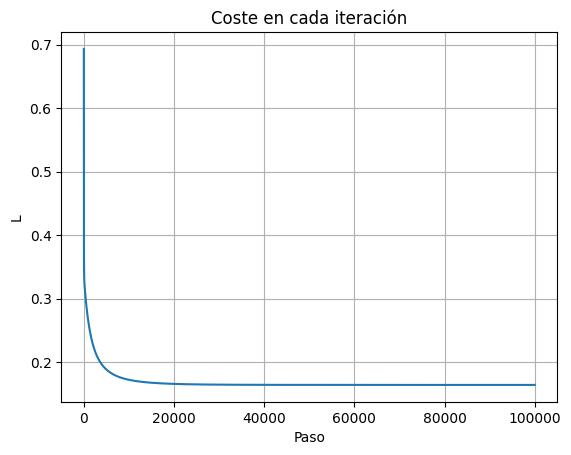

In [13]:
plt.plot(L)
plt.xlabel("Paso")
plt.ylabel("L")
plt.grid()
plt.title("Coste en cada iteración")

Text(0.5, 0, '$Coste$')

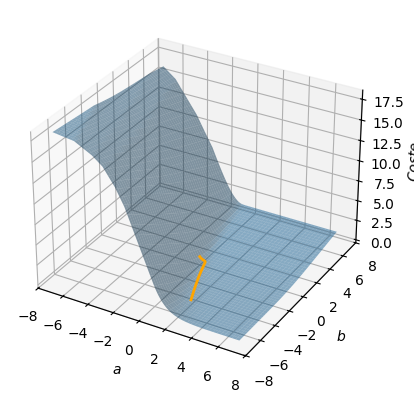

In [23]:
"""
Superficie de coste J(a, b)
Para cada par (a, b) de la rejilla calculamos el coste.
"""

a_vals = np.linspace(-7, 7, 1000)
b_vals = np.linspace(-7, 7, 1000)

A, B = np.meshgrid(a_vals, b_vals)

J = np.zeros([len(a_vals), len(b_vals)])

for i in range(len(a_vals)):
    for j in range(len(b_vals)):
        J[i, j] = coste(x,y,A[i, j],B[i, j])

fig = plt.figure()
ax = fig.add_subplot(111,projection="3d")
ax.plot_surface(A,B,J,alpha=0.5)
ax.plot(a_record, b_record, L, color="orange", linewidth = 2, zorder=5)
ax.set_xlabel("$a$")
ax.set_ylabel("$b$")
ax.set_zlabel("$Coste$");

En efecto, se ve que el camino del descenso termina cercano a a = 2, b = -5.